In [21]:
import pandas as pd

train_data = pd.read_csv('./data/kc_house_data.csv')
print('train data shape: ', train_data.shape)
print('train data columns: ', train_data.columns)
train_data.head()


train data shape:  (21613, 21)
train data columns:  Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [20]:
print(train_data['date'].sort_values(ascending=True))

16768    20140502T000000
9596     20140502T000000
9587     20140502T000000
20602    20140502T000000
11577    20140502T000000
              ...       
7898     20150514T000000
928      20150514T000000
5637     20150515T000000
13053    20150524T000000
16594    20150527T000000
Name: date, Length: 21613, dtype: object


(21613, 34)


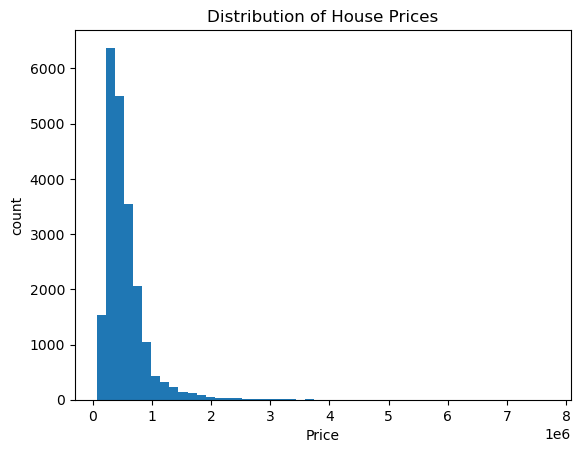

In [35]:
import pandas

sales_path = './data/kc_house_data.csv'
demographics_path = '/Users/kayla/phData/mle-project-challenge-2/app/data/zipcode_demographics.csv'
sales_column_selection = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]

data = pandas.read_csv(sales_path,
                        usecols=sales_column_selection,
                        dtype={'zipcode': str})
demographics = pandas.read_csv(demographics_path,
                                dtype={'zipcode': str})

merged_data = data.merge(demographics, how="left",
                            on="zipcode").drop(columns="zipcode")

print(merged_data.shape)

import matplotlib.pyplot as plt
plt.hist(train_data['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('count')
plt.title('Distribution of House Prices')
plt.show()

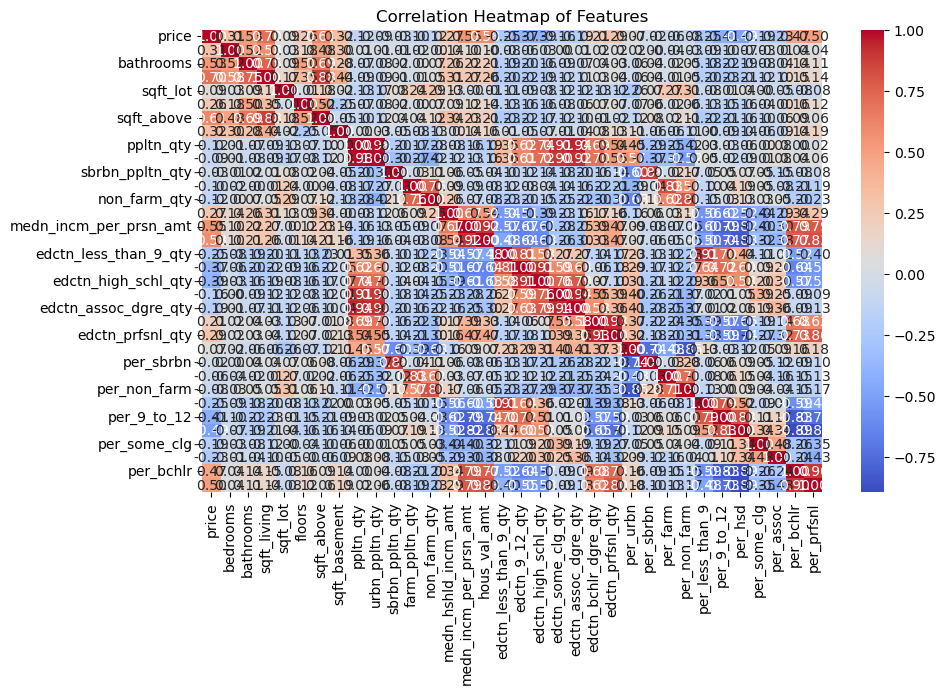

In [37]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(merged_data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

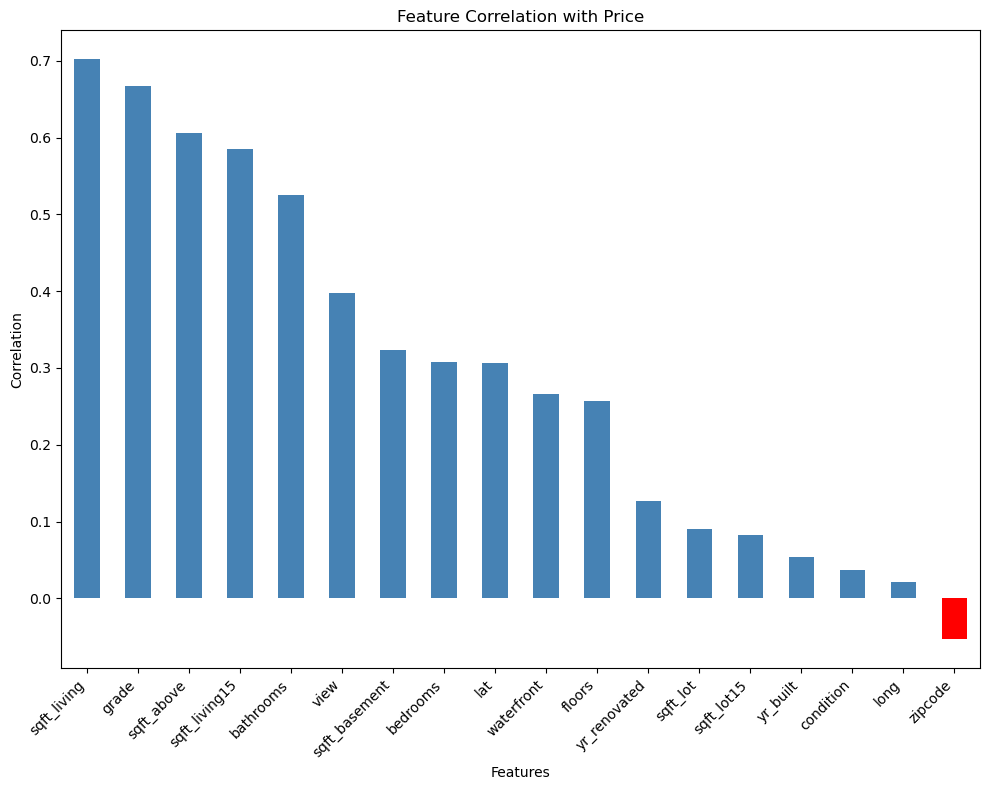

In [38]:
plt.figure(figsize=(10, 8))
price_corr = train_data.select_dtypes(include='number').drop(columns=['id']).corr()['price'].sort_values(ascending=False).drop('price')
price_corr.plot(kind='bar', color=['red' if x < 0 else 'steelblue' for x in price_corr])
plt.title('Feature Correlation with Price')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
print(train_data['yr_built'].head()
      )

0    1955
1    1951
2    1933
3    1965
4    1987
Name: yr_built, dtype: int64


In [8]:
features_data = pd.read_csv('./data/zipcode_demographics.csv')
print('features data shape: ', features_data.shape)
print('features data columns: ', features_data.columns)
features_data.head()

features data shape:  (70, 27)
features data columns:  Index(['ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty',
       'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt',
       'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty',
       'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty',
       'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn',
       'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd',
       'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl', 'zipcode'],
      dtype='object')


,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,farm_ppltn_qty,non_farm_qty,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt,edctn_less_than_9_qty,edctn_9_12_qty,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,zipcode
0,38249.0,37394.0,0.0,0.0,855.0,66051.0,25219.0,192000.0,437.0,2301.0,...,0.0,2.0,1.0,6.0,18.0,20.0,5.0,12.0,4.0,98042
1,22036.0,22036.0,0.0,0.0,0.0,91904.0,53799.0,573900.0,149.0,404.0,...,0.0,0.0,0.0,1.0,6.0,12.0,3.0,27.0,22.0,98040
2,18194.0,18194.0,0.0,0.0,0.0,61813.0,31765.0,246600.0,269.0,905.0,...,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,98028
3,21956.0,21956.0,0.0,0.0,0.0,47461.0,22158.0,175400.0,925.0,1773.0,...,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,98178
4,22814.0,22814.0,0.0,0.0,0.0,48606.0,28398.0,252600.0,599.0,1148.0,...,0.0,0.0,2.0,5.0,13.0,17.0,5.0,23.0,12.0,98007


In [9]:
test_fut_data = pd.read_csv('./data/future_unseen_examples.csv')
print('test data shape: ', test_fut_data.shape)
print('test data columns: ', test_fut_data.columns)
test_fut_data.head()

test data shape:  (100, 18)
test data columns:  Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,4,1.00,1680,5043,1.5,0,0,4,6,1680,0,1911,0,98118,47.5354,-122.273,1560,5765
1,3,2.50,2220,6380,1.5,0,0,4,8,1660,560,1931,0,98115,47.6974,-122.313,950,6380
2,3,2.25,1630,10962,1.0,0,0,4,8,1100,530,1977,0,98030,47.3801,-122.166,1830,8470
3,5,2.50,1710,9720,2.0,0,0,4,8,1710,0,1974,0,98005,47.5903,-122.157,2270,9672
4,2,1.00,850,6370,1.0,0,0,3,6,850,0,1951,0,98126,47.5198,-122.373,850,5170


In [ ]:
from train.create_model import load_data
import pandas
from typing import List, Tuple

SALES_PATH = "data/kc_house_data.csv"  # path to CSV with home sale data
DEMOGRAPHICS_PATH = "data/zipcode_demographics.csv"  # path to CSV with demographics
# List of columns (subset) that will be taken from home sale data
SALES_COLUMN_SELECTION = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]
def load_data(
    sales_path: str, demographics_path: str, sales_column_selection: List[str]
) -> Tuple[pandas.DataFrame, pandas.Series]:
    """Load the target and feature data by merging sales and demographics.

    Args:
        sales_path: path to CSV file with home sale data
        demographics_path: path to CSV file with home sale data
        sales_column_selection: list of columns from sales data to be used as
            features

    Returns:
        Tuple containg with two elements: a DataFrame and a Series of the same
        length.  The DataFrame contains features for machine learning, the
        series contains the target variable (home sale price).

    """
    data = pandas.read_csv(sales_path,
                           usecols=sales_column_selection,
                           dtype={'zipcode': str})
    demographics = pandas.read_csv("data/zipcode_demographics.csv",
                                   dtype={'zipcode': str})
    print('sales data shape: ', data.shape)
    print('demographics data shape: ', demographics.shape)

    merged_data = data.merge(demographics, how="left",
                             on="zipcode").drop(columns="zipcode")
    print('merged data shape: ', merged_data.shape)
    # Remove the target variable from the dataframe, features will remain
    y = merged_data.pop('price')
    x = merged_data

    return x, y
x,y = load_data(SALES_PATH, DEMOGRAPHICS_PATH, SALES_COLUMN_SELECTION)
print('x shape: ', x.shape)
print('y shape: ', y.shape)



sales data shape:  (21613, 9)
demographics data shape:  (70, 27)
merged data shape:  (21613, 34)
x shape:  (21613, 33)
y shape:  (21613,)


In [3]:
missing_values = x.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [21]:
import json
FEATURES_PATH = "model/knn_regressor_features.json"  # path to JSON file with list of features used in model
print('x columns: ', x.columns)
print('demo columns: ', features_data.columns)
features = json.load(open(FEATURES_PATH, 'r'))
print('features: ', features)

# Normalize for comparison
x_cols = [col.strip().lower() for col in x.columns]
features_set = set([f.strip().lower() for f in features])

# Find columns in x that are not in features
extra_in_x = [col for col in x_cols if col not in features_set]
print("Columns in x but not in features:", extra_in_x)

x columns:  Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'sqft_above', 'sqft_basement', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')
demo columns:  Index(['ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty',
       'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt',
       'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty',
       'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty',
       'edctn_bchlr_dgre_qty', 'edctn_prfsnl_q

In [15]:
# take in the fut_data as input, then merge with the demographics data to get the features for the fut_data
import json



INPUT_SELECTION = "model/knn_regressor_features.json"
with open(INPUT_SELECTION, 'r') as f:
    features = json.load(f)
print('features: ', features)
print('features length: ', len(features))

### determine if drop zip or not

def load_input_data(future_data_path, demographics_path, input_column_selection):
    future_data = pd.read_csv(future_data_path,
                              usecols=input_column_selection, 
                              dtype={'zipcode': str})
    demographics_data = pd.read_csv(demographics_path, dtype={'zipcode': str})

    return x_future_merged

x_future_merged = load_input_data('data/future_unseen_examples.csv', 'data/zipcode_demographics.csv', INPUT_SELECTION)
x_future_merged.head()
print('columns: ', x_future_merged.columns)
print('x_future_merged shape: ', x_future_merged.shape)


features:  ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl']
features length:  33


In [38]:
import json
test_data = pd.read_csv('data/future_unseen_examples.csv')
test_datadf = pd.DataFrame(test_data)
missing_values = test_datadf.isnull().sum()
# print("Missing values in each column of test_data:")
print(missing_values)

#test_sample = test_datadf.iloc[[0]].to_csv("test_data.csv",index=False)
#test_data.shape
test_sample = test_datadf.iloc[0].to_json("test_data.json")


bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [53]:
input_data = "test_data.json"

with open(input_data, 'r') as f:
        input_data = json.load(f)
if isinstance(input_data, dict):
    input_data_df = pd.DataFrame([input_data])
elif isinstance(input_data, list):
    input_data_df = pd.DataFrame(input_data)
else:
    raise ValueError("Input data must be a list of dictionaries or a single dictionary")

print(input_data_df.head())

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       4.0        1.0       1680.0    5043.0     1.5         0.0   0.0   

   condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0        4.0    6.0      1680.0            0.0    1911.0           0.0   

   zipcode      lat     long  sqft_living15  sqft_lot15  
0  98118.0  47.5354 -122.273         1560.0      5765.0  


In [54]:
SALES_COLUMN_SELECTION = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
] 
input_data_df = pd.DataFrame([input_data])  # convert single dict to DataFrame 
input_df = input_data_df[SALES_COLUMN_SELECTION]  # select only the columns used in training
input_df.loc[:,'zipcode'] = input_df['zipcode'].astype(int).astype(str)  # ensure zipcode is string for merging
demographics = pd.read_csv(DEMOGRAPHICS_PATH, dtype={'zipcode': str})

print('input features length before merge:', len(input_df.columns))
print('features json length', len(json.load(open(FEATURES_PATH, 'r'))))

merged_input = input_df.merge(demographics, how="left", on="zipcode").drop(columns="zipcode") 
print('input features length after merge:', len(merged_input.columns))  

input features length before merge: 8
features json length 33
input features length after merge: 33


In [55]:
merged_input.head()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,4.0,1.0,1680.0,5043.0,1.5,1680.0,0.0,40409.0,40409.0,0.0,...,0.0,0.0,0.0,9.0,9.0,17.0,15.0,4.0,11.0,6.0


In [8]:
import json
import pandas as pd
post_data = pd.read_csv("/Users/kayla/phData/mle-project-challenge-2/test/future_unseen_examples.csv")
post_datadf = pd.DataFrame(post_data)
#post_data.to_json("post_data.json", 

with open("post_data.json", 'w') as f:
    json.dump(post_data.to_dict(orient='records'), f)

data = pd.read_json("post_data.json")
data.shape

(100, 18)

In [22]:
single_set = data.sample(1)
print(single_set)
single_set.to_json("single_test_data.json", orient='records')


    bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
20         3       2.75         1560     77536     1.0           0     0   

    condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
20          3      7        1400            160      1978             0   

    zipcode      lat     long  sqft_living15  sqft_lot15  
20    98072  47.7695 -122.126           2210       41449  


In [ ]:
#create random 4 rows of data to test the model
data_subset = data.sample(4)
data_subset.shape
print(data_subset)
data_subset.to_json("random_subset_post_data.json", orient='records')

    bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
59         4        2.0         2750      5527     2.0           0     0   
35         4        2.5         2110      4178     2.0           0     0   
48         3        1.0         1020     13504     1.0           0     0   
39         3        1.0         1090      7315     1.0           0     0   

    condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
59          3      8        2130            620      1901          1987   
35          3      7        2110              0      2013             0   
48          5      7        1020              0      1959             0   
39          5      6        1090              0      1981             0   

    zipcode      lat     long  sqft_living15  sqft_lot15  
59    98119  47.6513 -122.368           1290        1764  
35    98042  47.3612 -122.081           2300        4142  
48    98056  47.5121 -122.170           1110       11158  
39    9

In [10]:
import numpy as np
import pandas as pd
import json

SALES_COLUMN_SELECTION = [
'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]

df = pd.read_csv("/Users/kayla/phData/mle-project-challenge-2/test/future_unseen_examples.csv", usecols=SALES_COLUMN_SELECTION, dtype={'zipcode': str})
print('df shape: ', df.shape)
print('df columns: ', df.columns)
simple_post = df.to_json("simple_post_data.json", orient='records')




df shape:  (100, 8)
df columns:  Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'sqft_above', 'sqft_basement', 'zipcode'],
      dtype='object')


In [14]:
data = pd.read_json("/Users/kayla/phData/mle-project-challenge-2/test/simple_post_data.json")
single=data.sample(1)
print(single)
single.to_json("/Users/kayla/phData/mle-project-challenge-2/test/simple_post_data_single.json", orient='records')
subset=data.sample(4)
print(subset)
subset.to_json("/Users/kayla/phData/mle-project-challenge-2/test/simple_post_data_subset.json", orient='records')


    bedrooms  bathrooms  sqft_living  sqft_lot  floors  sqft_above  \
46         4        2.5         2150      3721     2.0        2150   

    sqft_basement  zipcode  
46              0    98002  
    bedrooms  bathrooms  sqft_living  sqft_lot  floors  sqft_above  \
38         3       1.00          880     18109     1.0         880   
22         2       1.75         1160      6828     1.0         860   
88         4       2.50         2440      6733     2.0        2440   
15         3       1.50         1140      8500     1.0        1140   

    sqft_basement  zipcode  
38              0    98042  
22            300    98115  
88              0    98074  
15              0    98022  
